In [79]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [80]:
y = df_clean["price"]

In [ ]:
drop_columns = [

    "price",

    "price_per_sqm",

    "listing_id",

    "last_updated",

    "scraped_at",

    "complex_name"

]

In [ ]:
X = df_clean.drop(columns=drop_columns)

y = df_clean["price"]

In [ ]:
print(X.shape)

print(y.shape)

In [31]:
import pandas as pd

df_clean = pd.read_csv("../data/processed/featured_data.csv")

print(df_clean.shape)

(24753, 39)


C:\Users\Oyku\AppData\Local\Temp\ipykernel_3744\3162803459.py:3: DtypeWarning: Columns (0: last_updated) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("../data/processed/featured_data.csv")


In [32]:
print(df_clean.shape)
df_clean.head()

(24753, 39)


,listing_id,price,price_per_sqm,district,neighborhood,rooms,halls,total_rooms,gross_sqm,net_sqm,...,scraped_at,usable_area_ratio,sqm_difference,bathroom_per_room,floor_ratio,is_new_building,building_age_group,is_large_house,has_multiple_bathrooms,sqm_per_room
0,54895-1121,15900000,165625.00,Adalar,Maden,3,1,4,138.0,96.0,...,2026-03-14T20:38:29,0.695652,42.0,0.5,1.000000,0,40+,0,1,24.0
1,54895-1103,40000000,266666.67,Adalar,Nizam,4,1,5,199.0,150.0,...,2026-03-14T20:38:36,0.753769,49.0,0.8,-0.333333,1,0-5,1,1,30.0
2,54895-1148,17850000,220370.37,Adalar,Nizam,2,1,3,107.0,81.0,...,2026-03-14T20:38:47,0.757009,26.0,1.0,0.200000,0,40+,0,1,27.0
3,12854-258,16000000,81632.65,Adalar,Heybeliada,3,1,4,200.0,196.0,...,2026-03-14T20:38:56,0.980000,4.0,0.5,NaN,0,21-40,1,1,49.0
4,121334-99,14000000,96551.72,Adalar,Nizam,4,1,5,160.0,145.0,...,2026-03-14T20:39:04,0.906250,15.0,0.2,-0.333333,0,21-40,0,0,29.0


In [33]:
drop_columns = [
    "price",
    "price_per_sqm",
    "listing_id",
    "last_updated",
    "scraped_at",
    "complex_name"
]

X = df_clean.drop(columns=drop_columns)
y = df_clean["price"]

print(X.shape)
print(y.shape)

(24753, 33)
(24753,)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(19802, 33)
(4951, 33)
(19802,)
(4951,)


In [35]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print()

print("Categorical Features:")
print(categorical_features)

Numeric Features:
['rooms', 'halls', 'total_rooms', 'gross_sqm', 'net_sqm', 'floor', 'total_floors', 'building_age', 'bathroom_count', 'is_in_complex', 'maintenance_fee', 'usable_area_ratio', 'sqm_difference', 'bathroom_per_room', 'floor_ratio', 'is_new_building', 'is_large_house', 'has_multiple_bathrooms', 'sqm_per_room']

Categorical Features:
['district', 'neighborhood', 'floor_category', 'building_type', 'building_condition', 'heating_type', 'fuel_type', 'furnished', 'usage_status', 'orientation', 'credit_eligible', 'deed_status', 'exchange', 'building_age_group']


In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [37]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Sayısal:", len(numeric_features))
print("Kategorik:", len(categorical_features))

Sayısal: 19
Kategorik: 14


In [38]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [82]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [41]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [42]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['district','neighborhood','rooms',...,'is_large_house', 'has_multiple_bathrooms','sqm_per_room']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed t

In [43]:
predictions = model.predict(X_test)

In [44]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE : {mae:,.2f} TL")
print(f"RMSE: {rmse:,.2f} TL")
print(f"R²  : {r2:.4f}")

MAE : 4,006,136.87 TL
RMSE: 10,426,524.93 TL
R²  : 0.5778


In [45]:
from sklearn.ensemble import RandomForestRegressor

In [46]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [47]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['district','neighborhood','rooms',...,'is_large_house', 'has_multiple_bathrooms','sqm_per_room']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed t

In [48]:
rf_predictions = rf_model.predict(X_test)

In [49]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print(f"MAE : {rf_mae:,.2f} TL")
print(f"RMSE: {rf_rmse:,.2f} TL")
print(f"R²  : {rf_r2:.4f}")

MAE : 2,575,544.56 TL
RMSE: 8,376,967.06 TL
R²  : 0.7274


In [50]:
from xgboost import XGBRegressor


In [51]:
from xgboost import XGBRegressor

In [52]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                random_state=42
            ),
        ),
    ]
)

In [53]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['district','neighborhood','rooms',...,'is_large_house', 'has_multiple_bathrooms','sqm_per_room']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed t

In [84]:
xgb_predictions = xgb_model.predict(X_test)

In [85]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f"MAE : {xgb_mae:,.2f} TL")
print(f"RMSE: {xgb_rmse:,.2f} TL")
print(f"R²  : {xgb_r2:.4f}")

MAE : 2,762,588.50 TL
RMSE: 7,948,016.76 TL
R²  : 0.7546


In [56]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R²": [
        r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,4.006137e+06,1.042652e+07,0.577757
1,Random Forest,2.575545e+06,8.376967e+06,0.727443
2,XGBoost,2.762588e+06,7.948017e+06,0.754642


In [57]:
results.sort_values(by="R²", ascending=False)

,Model,MAE,RMSE,R²
2,XGBoost,2.762588e+06,7.948017e+06,0.754642
1,Random Forest,2.575545e+06,8.376967e+06,0.727443
0,Linear Regression,4.006137e+06,1.042652e+07,0.577757


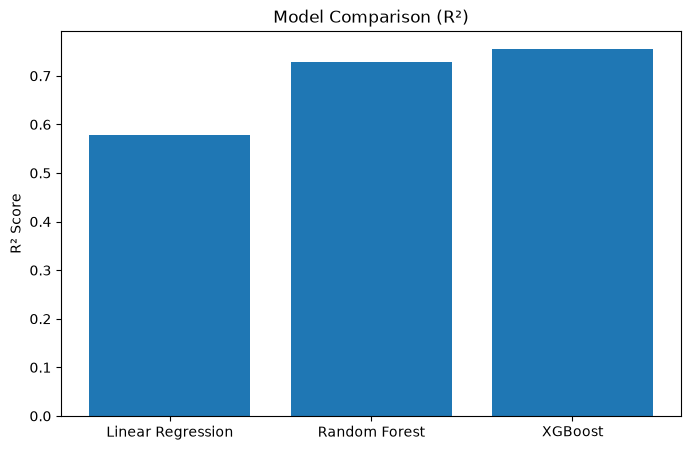

In [58]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R²"])

plt.title("Model Comparison (R²)")
plt.ylabel("R² Score")

plt.show()

In [59]:
import matplotlib.pyplot as plt

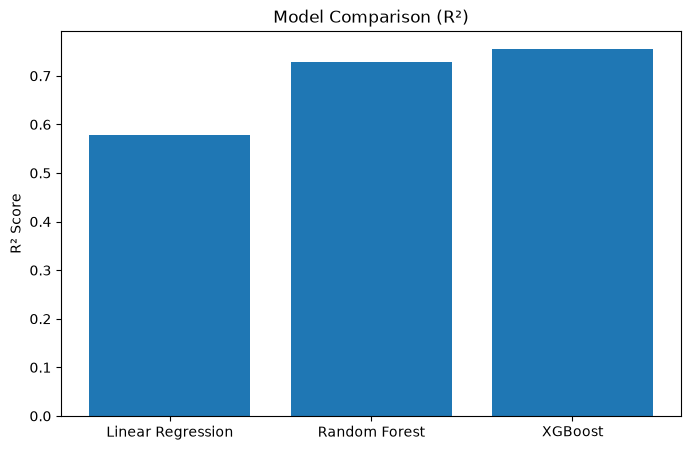

In [60]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R²"])

plt.title("Model Comparison (R²)")
plt.ylabel("R² Score")

plt.show()

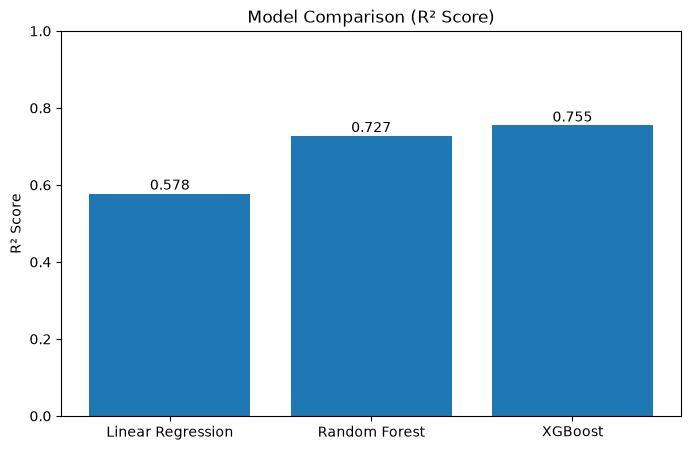

In [61]:
plt.figure(figsize=(8,5))

bars = plt.bar(results["Model"], results["R²"])

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.ylim(0, 1)

# Her çubuğun üstüne değerini yaz
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.show()

In [62]:
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

importances = xgb_model.named_steps["regressor"].feature_importances_

In [63]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [64]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
31,cat__district_Beşiktaş,0.105509
39,cat__district_Kadıköy,0.051426
589,cat__neighborhood_Çubuklu,0.046345
46,cat__district_Sarıyer,0.036055
3,num__gross_sqm,0.029059
24,cat__district_Bakırköy,0.028204
28,cat__district_Beykoz,0.027613
8,num__bathroom_count,0.025012
499,cat__neighborhood_Teşvikiye,0.024940
42,cat__district_Küçükçekmece,0.018575


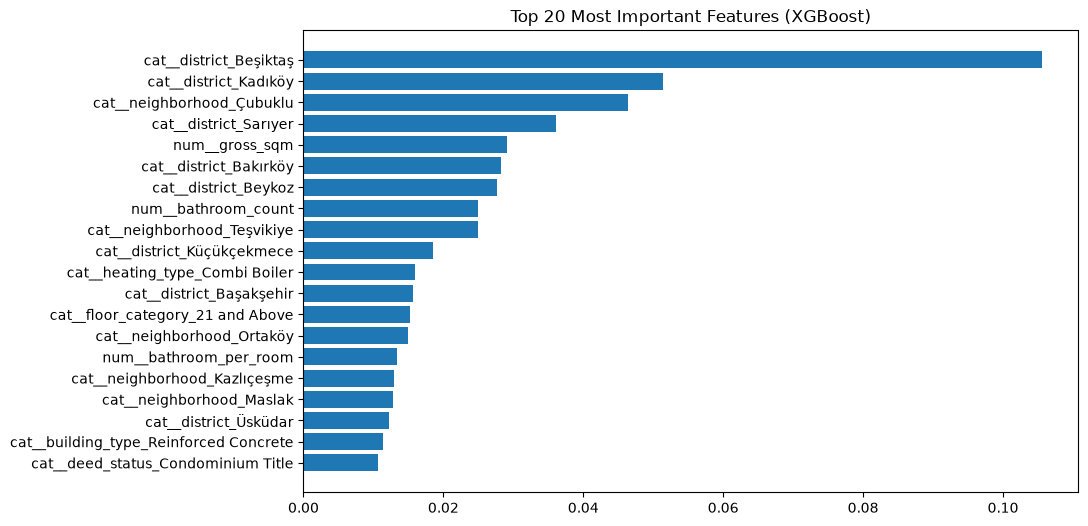

In [65]:
top20 = importance_df.head(20)

plt.figure(figsize=(10,6))

plt.barh(top20["Feature"], top20["Importance"])

plt.title("Top 20 Most Important Features (XGBoost)")

plt.gca().invert_yaxis()

plt.show()

In [66]:
from catboost import CatBoostRegressor

In [67]:
from catboost import CatBoostRegressor

cat_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            CatBoostRegressor(
                iterations=300,
                learning_rate=0.05,
                depth=6,
                random_state=42,
                verbose=0
            ),
        ),
    ]
)

In [68]:
cat_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](0,)",[]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['district','neighborhood','rooms',...,'is_large_house', 'has_multiple_bathrooms','sqm_per_room']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [69]:
cat_predictions = cat_model.predict(X_test)

In [70]:
cat_mae = mean_absolute_error(y_test, cat_predictions)
cat_rmse = np.sqrt(mean_squared_error(y_test, cat_predictions))
cat_r2 = r2_score(y_test, cat_predictions)

print(f"MAE : {cat_mae:,.2f} TL")
print(f"RMSE: {cat_rmse:,.2f} TL")
print(f"R²  : {cat_r2:.4f}")

MAE : 3,194,218.59 TL
RMSE: 8,655,167.80 TL
R²  : 0.7090


In [71]:
import shap

In [72]:
xgb_regressor = xgb_model.named_steps["regressor"]

In [73]:
X_test_processed = xgb_model.named_steps[
    "preprocessor"
].transform(X_test)

In [74]:
explainer = shap.TreeExplainer(xgb_regressor)

In [75]:
shap_values = explainer.shap_values(X_test_processed)

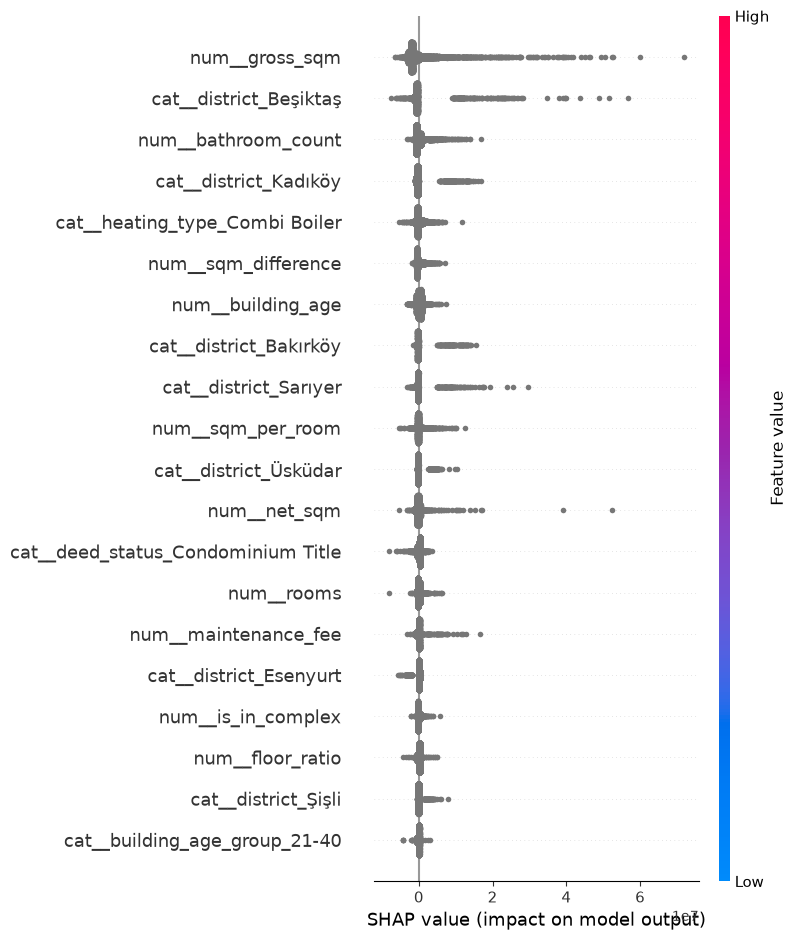

In [76]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

In [77]:
sample_index = 0

IndexError: index (31) out of range

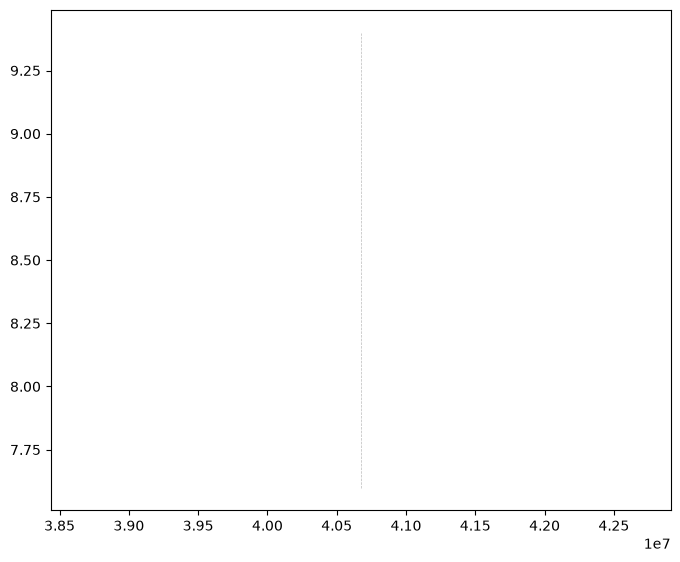

In [78]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test_processed[sample_index],
        feature_names=feature_names
    )
)

In [ ]:
type(X_test_processed)

In [ ]:
sample_data = X_test_processed[sample_index].toarray().flatten()

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=sample_data,
        feature_names=feature_names
    )
)

In [ ]:
import joblib

In [ ]:
joblib.dump(
    xgb_model,
    "../models/xgb_model.pkl"
)

In [ ]:
import os

os.listdir("../models")

In [ ]:
print(X.columns.tolist())

In [ ]:
import joblib

joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")

In [ ]:
import joblib

feature_columns = joblib.load("models/feature_columns.pkl")

for col in feature_columns:
    print(col)

In [ ]:
import os

print(os.getcwd())

In [ ]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

In [ ]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

In [ ]:
import joblib

feature_columns = joblib.load("../models/feature_columns.pkl")

for col in feature_columns:
    if "district" in col.lower():
        print(col)

In [ ]:
feature_columns[:50]

In [ ]:
districts = sorted(df["district"].dropna().unique().tolist())

districts[:10]

In [ ]:
districts = sorted(df_clean["district"].dropna().unique().tolist())